1. Loading Processed Macro-Dataset...


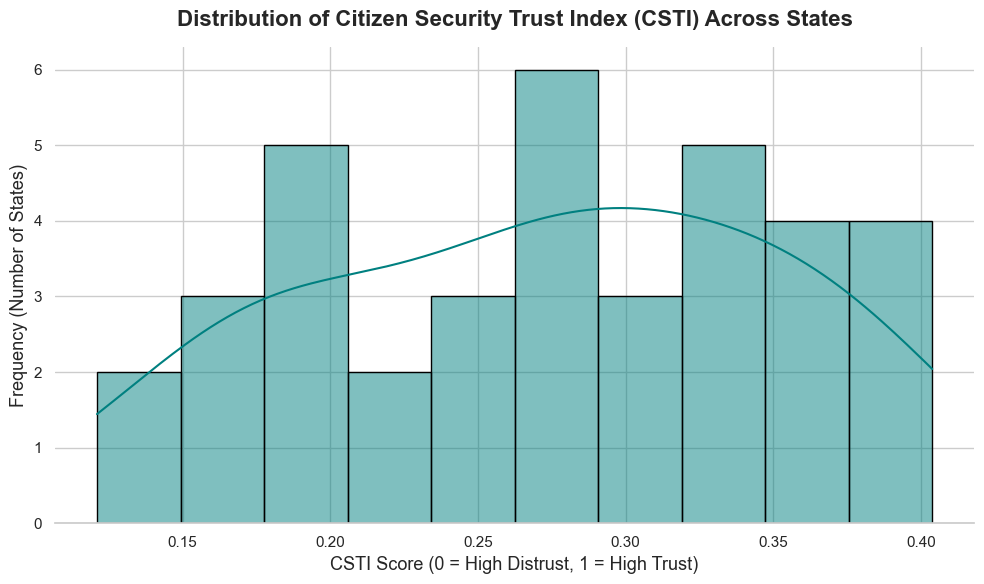

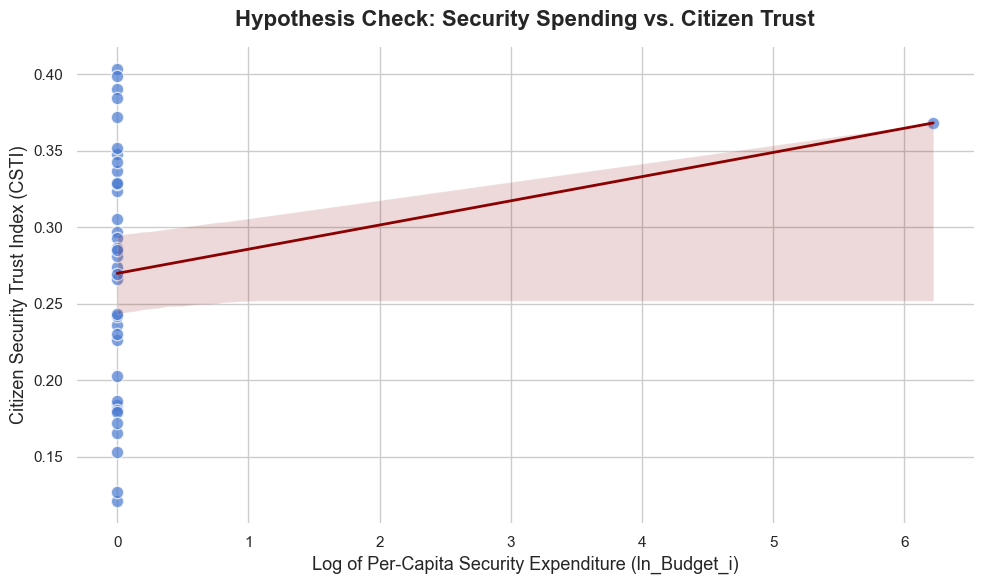

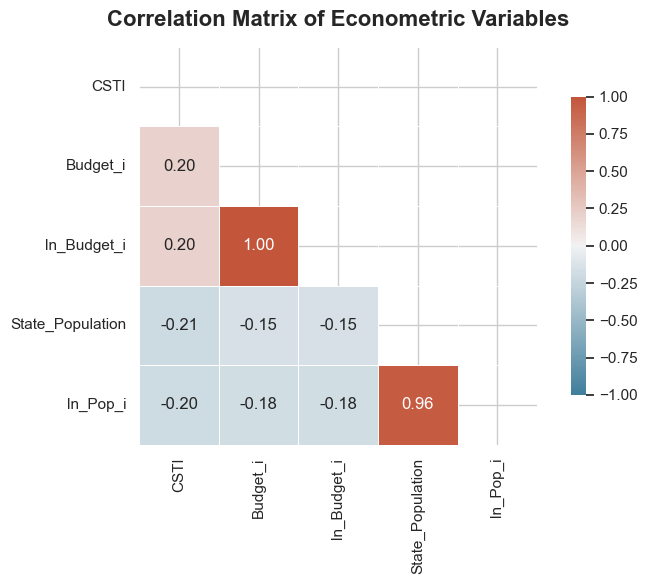

EDA Complete. Visualizations generated.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, academic visual style
sns.set_theme(style="whitegrid", palette="muted")

print("1. Loading Processed Macro-Dataset...")
# Load the dataset (adjust path if your notebook is in a different directory level)
df = pd.read_csv("../data/processed/csti_master_dataset.csv")

# Ensure our logarithmic population control exists for the correlation matrix
if 'ln_Pop_i' not in df.columns:
    df['ln_Pop_i'] = np.log(df['State_Population'])

# ==========================================
# 2. UNIVARIATE ANALYSIS: DISTRIBUTION OF TRUST
# ==========================================
plt.figure(figsize=(10, 6))
sns.histplot(df['CSTI'], bins=10, kde=True, color='teal', edgecolor='black')
plt.title('Distribution of Citizen Security Trust Index (CSTI) Across States', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('CSTI Score (0 = High Distrust, 1 = High Trust)', fontsize=13)
plt.ylabel('Frequency (Number of States)', fontsize=13)
sns.despine(left=True)
plt.tight_layout()
plt.show()

# ==========================================
# 3. BIVARIATE ANALYSIS: SPENDING VS. TRUST
# ==========================================
plt.figure(figsize=(10, 6))
# Using regplot to instantly see if there is a linear relationship
sns.regplot(
    x='ln_Budget_i', 
    y='CSTI', 
    data=df, 
    scatter_kws={'alpha': 0.7, 's': 80, 'edgecolor': 'w'}, 
    line_kws={'color': 'darkred', 'linewidth': 2}
)
plt.title('Hypothesis Check: Security Spending vs. Citizen Trust', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Log of Per-Capita Security Expenditure (ln_Budget_i)', fontsize=13)
plt.ylabel('Citizen Security Trust Index (CSTI)', fontsize=13)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# ==========================================
# 4. MULTIVARIATE ANALYSIS: CORRELATION HEATMAP
# ==========================================
plt.figure(figsize=(8, 6))
# Select only the numerical variables for the correlation matrix
corr_cols = ['CSTI', 'Budget_i', 'ln_Budget_i', 'State_Population', 'ln_Pop_i']
corr_matrix = df[corr_cols].corr()

# Create a heatmap with a diverging color palette
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap=cmap, 
    vmax=1.0, 
    vmin=-1.0, 
    center=0, 
    annot=True, 
    fmt=".2f", 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .75}
)
plt.title('Correlation Matrix of Econometric Variables', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("EDA Complete. Visualizations generated.")